# Figure 3: Copy # Correction

**Goal:**

Present the copy number correction story: Copy number correction amends differential replication effects on gene expression and chromatin.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [202]:
from src.Figure3_Copy_Correction import Figure3CopyCorrection
from src.figure_configs import save_figure_for_paper

figures = Figure3CopyCorrection()

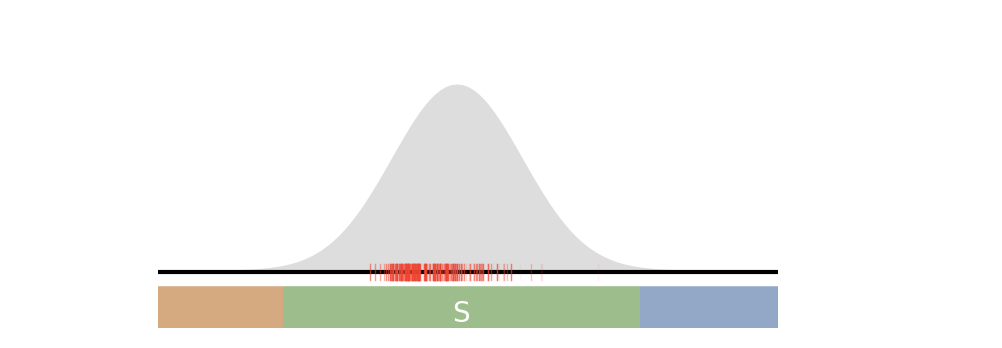

In [203]:
figures.plot_S_diagram()

10, 00:00:09.060
10, 00:00:08.807
Deconvolving with config: shared, <class 'src.single_G1_config.Config'>, <function calcH at 0x7fd5a21e5ee0>


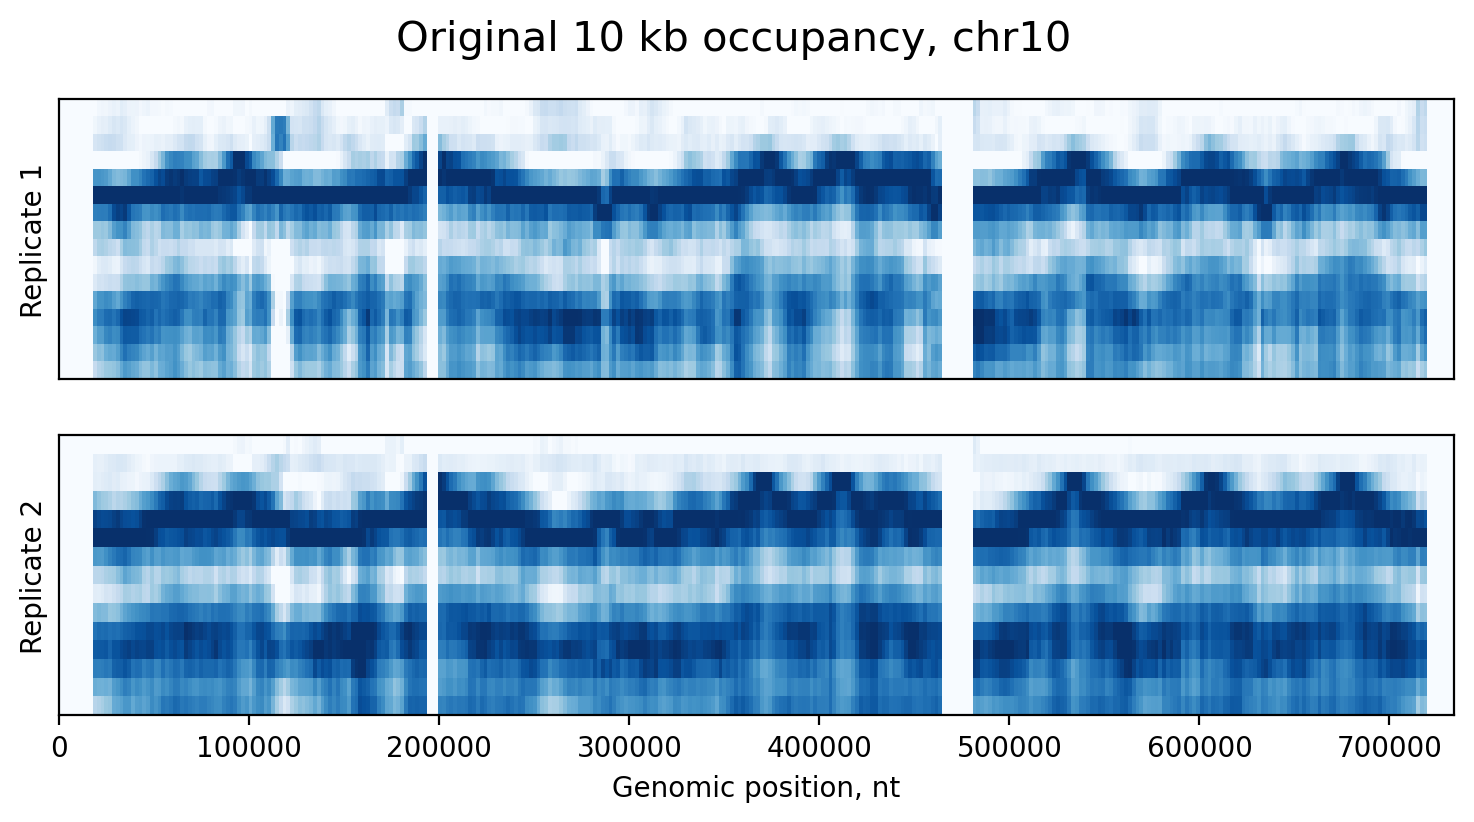

In [204]:
figures.plot_raw_replication_chr10()
save_figure_for_paper('output/figures/Copy_Correction/Raw_10kb_chr10.png')

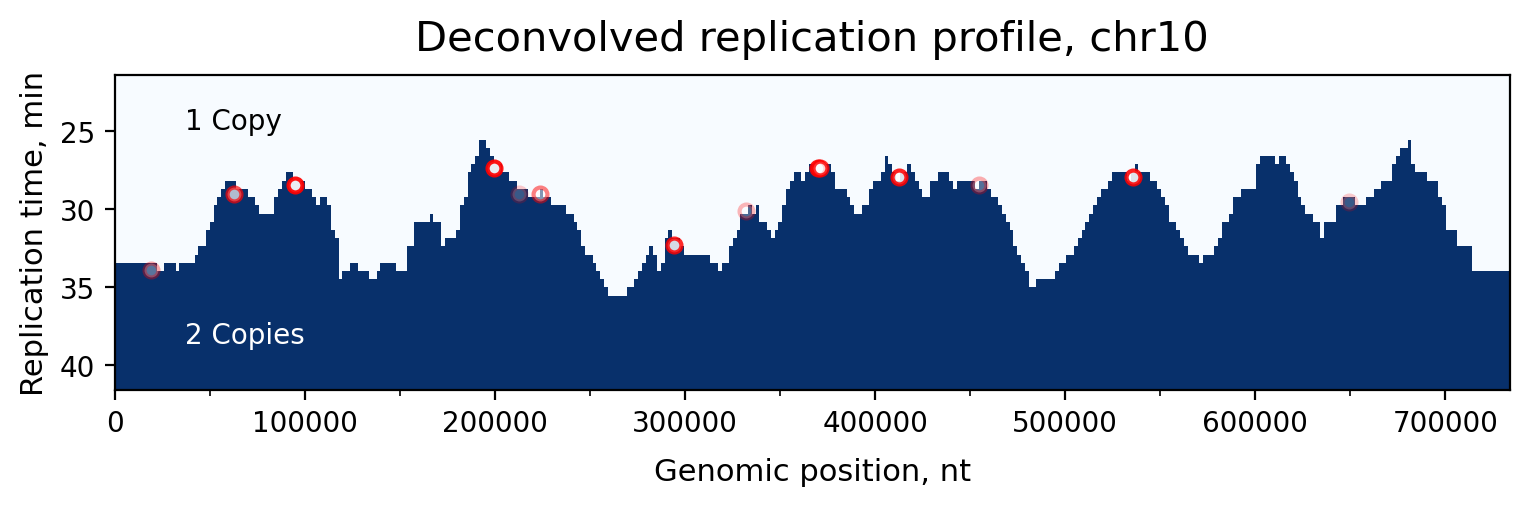

In [196]:
figures.plot_replication_profile_example()
save_figure_for_paper('output/figures/Copy_Correction/Replication_Deconvolution_chr10.png')

# Chromatin Analysis

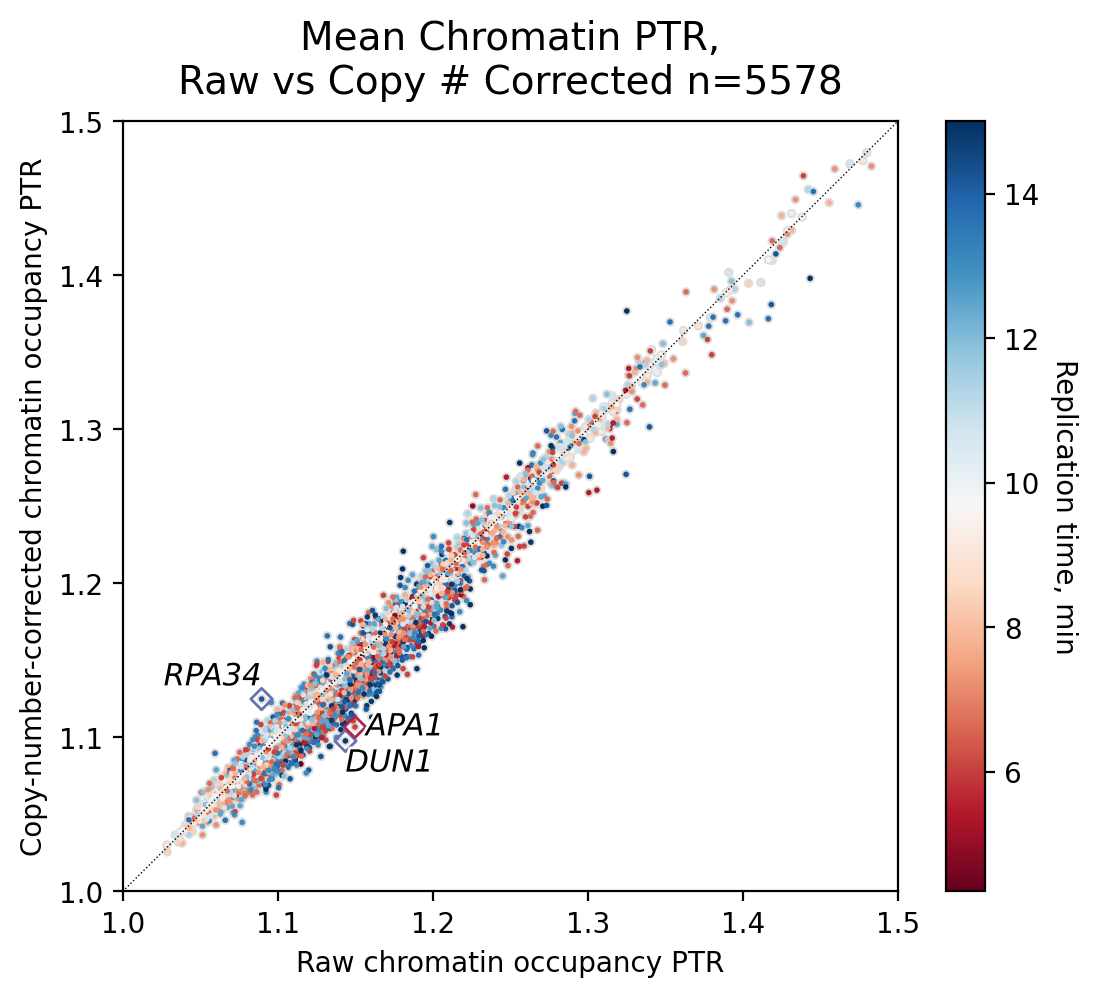

In [237]:
# Selected genes based on increase/decrease in PTR
figures.selected_chrom_genes = ['RPA34', # Increase
    'DUN1', # Decrease, Late
    'APA1', # Decrease, Early
]

figures.plot_chrom_ptr_correction()

save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Chromatin_PTR.png')

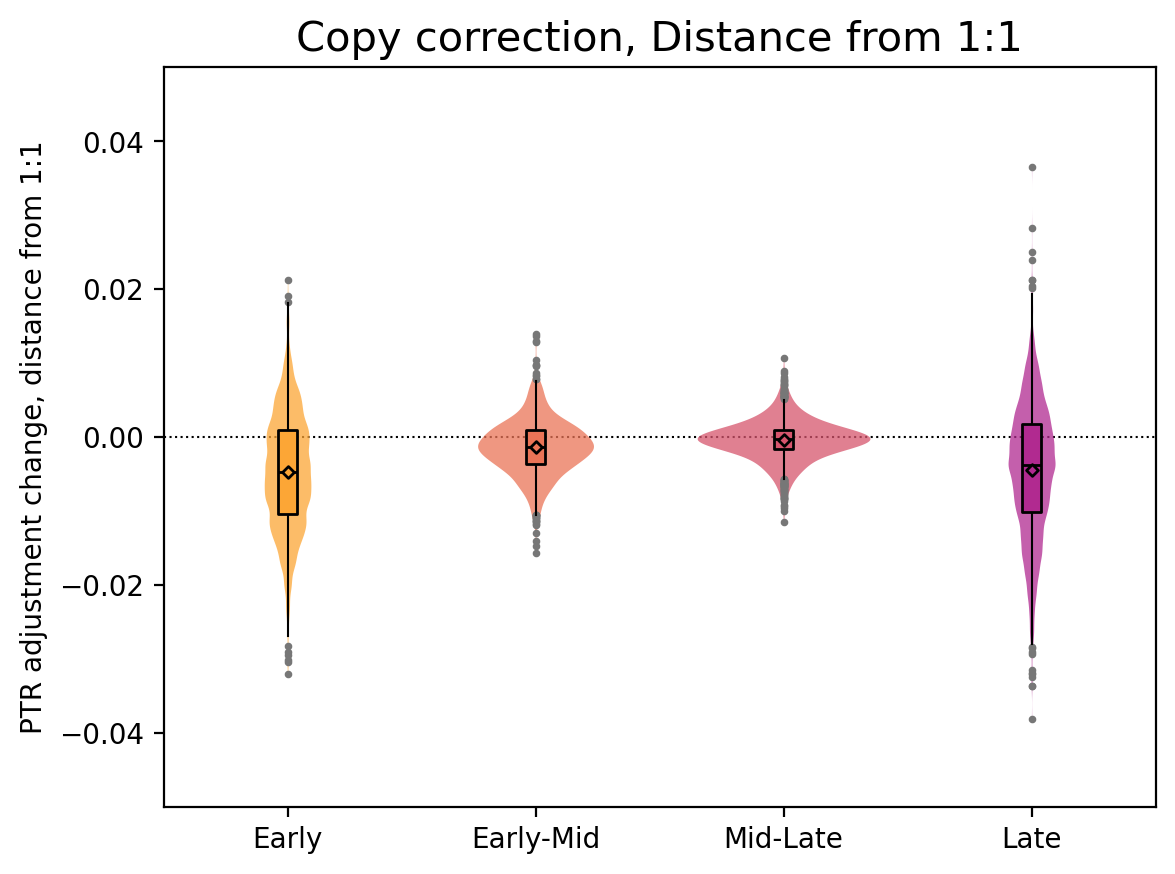

In [382]:
figures.plot_violin_ptr_11()
save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Chromatin_PTR_Violins.png')

In [412]:
from src.sgd import read_sgd_file, read_sgd_w_go

# Read in the ORFs and determine what needs to be modified or included for the gene ontology
# analysis

sgd_rows = read_sgd_w_go()

In [418]:
from src.gene_ontology import GeneOntology

gene_ontology = GeneOntology()
#sgd_rows#.iloc[4].desc

data/go.obo: fmt(1.2) rel(2018-08-29) 47,313 Terms


In [435]:
selected_genes = figures.mean_chrom_ptrs_w_distances_11.sort_values('distance_11')
selected_genes[]

group_name
Late         1641
Early-Mid    1397
Mid-Late     1297
Early        1243
Name: count, dtype: int64

In [434]:
selected_orfs = selected_genes.tail(400).index.values

In [430]:
gene_ontology.run_go(selected_orfs)

In [431]:
gene_ontology.results_sig_df

,id,name,pop_count,pop_n,study_count,study_n,pop_items,study_items,fdr_bh,bonferroni
0,GO:0008150,biological_process,2000,6575,56,63,"YGL082W,BSC5,YBR277C,YAR047C,TMA17,YJL077W-A,Y...","YCL049C,YFR017C,YDR169C-A,YGL036W,YNL035C,YMR3...",1.179413e-18,1.179413e-18
1,GO:0003674,molecular_function,2777,6575,60,63,"CIS1,YGL082W,RRP15,BSC5,YBR277C,SQS1,YAR047C,T...","YCL049C,YFR017C,YDR169C-A,YGL036W,YNL035C,YMR3...",3.565029e-16,7.130057e-16
2,GO:0005575,cellular_component,1563,6575,36,63,"BSC5,YBR277C,SRY1,YAR047C,RKM2,YJL077W-A,YPL03...","YDR169C-A,YMR317W,YBR063C,YDL241W,YBR221W-A,YH...",1.448818e-05,4.346454e-05
